In [1]:
# ============================================================
# COLIDE — EDA NOTEBOOK
# Cell 1: Setup & Reproducibility
# ============================================================

# ------------------------------------------------------------
# Standard Library Imports
# ------------------------------------------------------------
import os
import random
import warnings
from pathlib import Path

# ------------------------------------------------------------
# Data Science Libraries
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import torch

# ------------------------------------------------------------
# Warning Configuration
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Global Reproducibility Seed
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Pandas Display Settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# ------------------------------------------------------------
# Plot Styling
# Publication-grade defaults
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["legend.fontsize"] = 10

# ------------------------------------------------------------
# Paths
# Notebook runs from notebooks/
# ------------------------------------------------------------
NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_DATA_DIR = PROJECT_ROOT / "data" / "splits"

OUTPUT_DIR = PROJECT_ROOT / "notebooks"

# ------------------------------------------------------------
# Load Configuration
# ------------------------------------------------------------
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

# ------------------------------------------------------------
# Environment Summary
# ------------------------------------------------------------
print("=" * 70)
print("COLIDE — EDA ENVIRONMENT INITIALIZED")
print("=" * 70)

print(f"Project Root        : {PROJECT_ROOT}")
print(f"Config Path         : {CONFIG_PATH}")
print(f"Raw Data Directory  : {RAW_DATA_DIR}")
print(f"Processed Directory : {PROCESSED_DATA_DIR}")
print(f"Splits Directory    : {SPLITS_DATA_DIR}")

print("\nReproducibility")
print("-" * 70)
print(f"Seed: {SEED}")

print("\nCUDA Available")
print("-" * 70)
print(torch.cuda.is_available())

print("\nConfiguration Loaded Successfully")
print("-" * 70)
print("Ready for EDA")

print("\n✅ Cell 1 Complete")

COLIDE — EDA ENVIRONMENT INITIALIZED
Project Root        : /home/titoisalive/colide
Config Path         : /home/titoisalive/colide/config/config.yaml
Raw Data Directory  : /home/titoisalive/colide/data/raw
Processed Directory : /home/titoisalive/colide/data/processed
Splits Directory    : /home/titoisalive/colide/data/splits

Reproducibility
----------------------------------------------------------------------
Seed: 42

CUDA Available
----------------------------------------------------------------------
True

Configuration Loaded Successfully
----------------------------------------------------------------------
Ready for EDA

✅ Cell 1 Complete


In [2]:
# ============================================================
# Cell 2: Load Data & Initial Dataset Inspection
# ============================================================

# ------------------------------------------------------------
# Dataset File Paths
# ------------------------------------------------------------
TRAIN_FILE = RAW_DATA_DIR / "UNSW_2018_IoT_Botnet_Final_10_best_Training.csv"
TEST_FILE = RAW_DATA_DIR / "UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv"

# ------------------------------------------------------------
# Verify Files Exist
# ------------------------------------------------------------
assert TRAIN_FILE.exists(), f"Training file not found: {TRAIN_FILE}"
assert TEST_FILE.exists(), f"Testing file not found: {TEST_FILE}"

print("✅ Dataset files located successfully")

# ------------------------------------------------------------
# Load Datasets
# IMPORTANT:
# Dataset is COMMA-SEPARATED
# Do NOT use sep=';'
# ------------------------------------------------------------
print("\nLoading training dataset...")
df_train = pd.read_csv(TRAIN_FILE)

print("Loading testing dataset...")
df_test = pd.read_csv(TEST_FILE)

# ------------------------------------------------------------
# Dataset Shapes
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print(f"Training Shape : {df_train.shape}")
print(f"Testing Shape  : {df_test.shape}")

# ------------------------------------------------------------
# Expected Schema Validation
# ------------------------------------------------------------
EXPECTED_COLUMNS = [
    'pkSeqID',
    'proto',
    'saddr',
    'sport',
    'daddr',
    'dport',
    'seq',
    'stddev',
    'N_IN_Conn_P_SrcIP',
    'min',
    'state_number',
    'mean',
    'N_IN_Conn_P_DstIP',
    'drate',
    'srate',
    'max',
    'attack',
    'category',
    'subcategory'
]

print("\n" + "=" * 70)
print("SCHEMA VALIDATION")
print("=" * 70)

missing_cols = set(EXPECTED_COLUMNS) - set(df_train.columns)
extra_cols = set(df_train.columns) - set(EXPECTED_COLUMNS)

print(f"Expected Columns : {len(EXPECTED_COLUMNS)}")
print(f"Actual Columns   : {len(df_train.columns)}")

if len(missing_cols) == 0 and len(extra_cols) == 0:
    print("✅ Schema matches expected structure")
else:
    print("⚠ Schema differs from expected")
    print("Missing:", missing_cols)
    print("Extra:", extra_cols)

# ------------------------------------------------------------
# Column Names
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for idx, col in enumerate(df_train.columns, start=1):
    print(f"{idx:02d}. {col}")

# ------------------------------------------------------------
# Data Types
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TRAINING DATA TYPES")
print("=" * 70)

display(
    pd.DataFrame({
        "column": df_train.columns,
        "dtype": df_train.dtypes.astype(str).values
    })
)

# ------------------------------------------------------------
# First 3 Rows
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FIRST 3 TRAINING ROWS")
print("=" * 70)

display(df_train.head(3))

# ------------------------------------------------------------
# Memory Usage Report
# ------------------------------------------------------------
def dataframe_memory_mb(df):
    """
    Calculate dataframe memory usage in MB.
    """
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

train_mem = dataframe_memory_mb(df_train)
test_mem = dataframe_memory_mb(df_test)

print("\n" + "=" * 70)
print("DATAFRAME MEMORY USAGE")
print("=" * 70)

print(f"Training Dataset : {train_mem:.2f} MB")
print(f"Testing Dataset  : {test_mem:.2f} MB")

# ------------------------------------------------------------
# Quick Column Category Preview
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("COLUMN TYPE SUMMARY")
print("=" * 70)

numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric Columns : {len(numeric_cols)}")
print(f"Object Columns  : {len(object_cols)}")

print("\nNumeric:")
print(numeric_cols)

print("\nCategorical/Object:")
print(object_cols)

print("\n✅ Cell 2 Complete")

✅ Dataset files located successfully

Loading training dataset...
Loading testing dataset...

DATASET SHAPES
Training Shape : (2934817, 19)
Testing Shape  : (733705, 19)

SCHEMA VALIDATION
Expected Columns : 19
Actual Columns   : 19
✅ Schema matches expected structure

COLUMN NAMES
01. pkSeqID
02. proto
03. saddr
04. sport
05. daddr
06. dport
07. seq
08. stddev
09. N_IN_Conn_P_SrcIP
10. min
11. state_number
12. mean
13. N_IN_Conn_P_DstIP
14. drate
15. srate
16. max
17. attack
18. category
19. subcategory

TRAINING DATA TYPES


,column,dtype
0,pkSeqID,int64
1,proto,str
2,saddr,str
3,sport,str
4,daddr,str
5,dport,str
6,seq,int64
7,stddev,float64
8,N_IN_Conn_P_SrcIP,int64
9,min,float64



FIRST 3 TRAINING ROWS


,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory
0,3142762,udp,192.168.100.150,6551,192.168.100.3,80,251984,1.9004,100,0.0000,4,2.6875,100,0.0000,0.4945,4.0316,1,DDoS,UDP
1,2432264,tcp,192.168.100.150,5532,192.168.100.3,80,256724,0.0780,38,3.8569,3,3.9349,100,0.0000,0.2565,4.0129,1,DDoS,TCP
2,1976315,tcp,192.168.100.147,27165,192.168.100.3,80,62921,0.2687,100,2.9741,3,3.3414,100,0.0000,0.2949,3.6092,1,DDoS,TCP



DATAFRAME MEMORY USAGE
Training Dataset : 1354.42 MB
Testing Dataset  : 338.60 MB

COLUMN TYPE SUMMARY
Numeric Columns : 12
Object Columns  : 7

Numeric:
['pkSeqID', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack']

Categorical/Object:
['proto', 'saddr', 'sport', 'daddr', 'dport', 'category', 'subcategory']

✅ Cell 2 Complete


In [3]:
# ============================================================
# Cell 3: Data Quality Assessment
# ============================================================

# ------------------------------------------------------------
# Helper Function
# ------------------------------------------------------------
def missing_value_report(df, dataset_name):
    """
    Generate missing value summary.
    """

    missing_count = df.isnull().sum()

    missing_percentage = (
        missing_count / len(df)
    ) * 100

    report = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    })

    report = report.sort_values(
        by="missing_count",
        ascending=False
    )

    return report


# ============================================================
# TRAINING DATA QUALITY
# ============================================================

print("=" * 70)
print("TRAINING DATA QUALITY REPORT")
print("=" * 70)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------
train_missing_report = missing_value_report(
    df_train,
    "Training"
)

train_total_missing = int(
    df_train.isnull().sum().sum()
)

print(f"\nTotal Missing Cells: {train_total_missing:,}")

if train_total_missing == 0:
    print("✅ No missing values detected")
else:
    display(
        train_missing_report[
            train_missing_report["missing_count"] > 0
        ]
    )

# ------------------------------------------------------------
# Duplicate Rows
# ------------------------------------------------------------
train_duplicate_rows = int(
    df_train.duplicated().sum()
)

print(f"\nDuplicate Rows: {train_duplicate_rows:,}")

# ------------------------------------------------------------
# Infinite Values
# ------------------------------------------------------------
train_inf_count = np.isinf(
    df_train.select_dtypes(include=[np.number])
).sum().sum()

print(f"Infinite Values: {train_inf_count:,}")

# ============================================================
# TESTING DATA QUALITY
# ============================================================

print("\n" + "=" * 70)
print("TESTING DATA QUALITY REPORT")
print("=" * 70)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------
test_missing_report = missing_value_report(
    df_test,
    "Testing"
)

test_total_missing = int(
    df_test.isnull().sum().sum()
)

print(f"\nTotal Missing Cells: {test_total_missing:,}")

if test_total_missing == 0:
    print("✅ No missing values detected")
else:
    display(
        test_missing_report[
            test_missing_report["missing_count"] > 0
        ]
    )

# ------------------------------------------------------------
# Duplicate Rows
# ------------------------------------------------------------
test_duplicate_rows = int(
    df_test.duplicated().sum()
)

print(f"\nDuplicate Rows: {test_duplicate_rows:,}")

# ------------------------------------------------------------
# Infinite Values
# ------------------------------------------------------------
test_inf_count = np.isinf(
    df_test.select_dtypes(include=[np.number])
).sum().sum()

print(f"Infinite Values: {test_inf_count:,}")

# ============================================================
# COLUMN-LEVEL DTYPE REPORT
# ============================================================

print("\n" + "=" * 70)
print("COLUMN DTYPE & MEMORY REPORT")
print("=" * 70)

dtype_report = pd.DataFrame({
    "column": df_train.columns,
    "dtype": df_train.dtypes.astype(str),
    "memory_mb": (
        df_train.memory_usage(deep=True)[1:] /
        (1024 ** 2)
    ).values
})

dtype_report["memory_mb"] = (
    dtype_report["memory_mb"]
    .round(4)
)

dtype_report = dtype_report.sort_values(
    by="memory_mb",
    ascending=False
)

display(dtype_report)

# ============================================================
# OBJECT COLUMN REVIEW
# ============================================================

print("\n" + "=" * 70)
print("CATEGORICAL / OBJECT COLUMNS")
print("=" * 70)

object_cols = df_train.select_dtypes(
    include=["object"]
).columns.tolist()

for col in object_cols:

    unique_count = df_train[col].nunique()

    print(
        f"{col:<15} "
        f"Unique Values: {unique_count:,}"
    )

# ============================================================
# DATA QUALITY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

print(f"Train Missing Cells : {train_total_missing:,}")
print(f"Test Missing Cells  : {test_total_missing:,}")

print(f"Train Duplicates    : {train_duplicate_rows:,}")
print(f"Test Duplicates     : {test_duplicate_rows:,}")

print(f"Train Infinities    : {train_inf_count:,}")
print(f"Test Infinities     : {test_inf_count:,}")

print("\n✅ Data quality assessment complete")

TRAINING DATA QUALITY REPORT

Total Missing Cells: 0
✅ No missing values detected

Duplicate Rows: 0
Infinite Values: 0

TESTING DATA QUALITY REPORT

Total Missing Cells: 0
✅ No missing values detected

Duplicate Rows: 0
Infinite Values: 0

COLUMN DTYPE & MEMORY REPORT


,column,dtype,memory_mb
saddr,saddr,str,179.1060
daddr,daddr,str,173.5496
sport,sport,str,150.6620
category,category,str,147.7767
subcategory,subcategory,str,146.1972
proto,proto,str,145.5476
dport,dport,str,142.8861
pkSeqID,pkSeqID,int64,22.3909
N_IN_Conn_P_SrcIP,N_IN_Conn_P_SrcIP,int64,22.3909
stddev,stddev,float64,22.3909



CATEGORICAL / OBJECT COLUMNS
proto           Unique Values: 5
saddr           Unique Values: 20
sport           Unique Values: 65,541
daddr           Unique Values: 81
dport           Unique Values: 6,906
category        Unique Values: 5
subcategory     Unique Values: 8

DATA QUALITY SUMMARY
Train Missing Cells : 0
Test Missing Cells  : 0
Train Duplicates    : 0
Test Duplicates     : 0
Train Infinities    : 0
Test Infinities     : 0

✅ Data quality assessment complete


In [4]:
# ============================================================
# Cell 4: Label Column Analysis
# ============================================================

print("=" * 70)
print("LABEL COLUMN ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Attack Column (Binary)
# ------------------------------------------------------------
print("\n[1] ATTACK COLUMN")
print("-" * 70)

attack_counts = (
    df_train["attack"]
    .value_counts(dropna=False)
    .sort_index()
)

attack_pct = (
    df_train["attack"]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

attack_summary = pd.DataFrame({
    "count": attack_counts,
    "percentage": attack_pct.round(4)
})

display(attack_summary)

# ------------------------------------------------------------
# Category Column (Multiclass)
# ------------------------------------------------------------
print("\n[2] CATEGORY COLUMN")
print("-" * 70)

category_counts = (
    df_train["category"]
    .value_counts()
)

category_pct = (
    df_train["category"]
    .value_counts(normalize=True) * 100
)

category_summary = pd.DataFrame({
    "count": category_counts,
    "percentage": category_pct.round(4)
})

display(category_summary)

# ------------------------------------------------------------
# Subcategory Column
# ------------------------------------------------------------
print("\n[3] SUBCATEGORY COLUMN")
print("-" * 70)

subcategory_counts = (
    df_train["subcategory"]
    .value_counts()
)

subcategory_pct = (
    df_train["subcategory"]
    .value_counts(normalize=True) * 100
)

subcategory_summary = pd.DataFrame({
    "count": subcategory_counts,
    "percentage": subcategory_pct.round(4)
})

display(subcategory_summary)

# ------------------------------------------------------------
# Class Discovery
# ------------------------------------------------------------
class_names = sorted(
    df_train["category"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

num_classes = len(class_names)

print("\n" + "=" * 70)
print("DISCOVERED CATEGORY CLASSES")
print("=" * 70)

for idx, cls in enumerate(class_names, start=1):
    print(f"{idx:02d}. {cls}")

print(f"\nTotal Classes: {num_classes}")

# ------------------------------------------------------------
# Label Selection
# ------------------------------------------------------------
LABEL_COL = "category"

print("\n" + "=" * 70)
print("LABEL COLUMN DECISION")
print("=" * 70)

print(
"""
attack:
    Binary indicator (0 = normal, 1 = attack)

category:
    Attack family label
    Suitable for multiclass classification

subcategory:
    Fine-grained protocol/attack subtype
    Better suited for future experiments

COLIDE objective:
    Multiclass CNN-BiLSTM IDS

Selected label:
    category
"""
)

print(f"\n✅ LABEL_COL = '{LABEL_COL}'")

# ------------------------------------------------------------
# Sanity Checks
# ------------------------------------------------------------
assert LABEL_COL in df_train.columns
assert LABEL_COL in df_test.columns

print("\n✅ Label column analysis completed")

LABEL COLUMN ANALYSIS

[1] ATTACK COLUMN
----------------------------------------------------------------------


,count,percentage
attack,,
0,370,0.0126
1,2934447,99.9874



[2] CATEGORY COLUMN
----------------------------------------------------------------------


,count,percentage
category,,
DDoS,1541315,52.5183
DoS,1320148,44.9823
Reconnaissance,72919,2.4846
Normal,370,0.0126
Theft,65,0.0022



[3] SUBCATEGORY COLUMN
----------------------------------------------------------------------


,count,percentage
subcategory,,
UDP,1584650,53.9948
TCP,1274843,43.4386
Service_Scan,58626,1.9976
OS_Fingerprint,14293,0.4870
HTTP,1970,0.0671
Normal,370,0.0126
Keylogging,59,0.0020
Data_Exfiltration,6,0.0002



DISCOVERED CATEGORY CLASSES
01. DDoS
02. DoS
03. Normal
04. Reconnaissance
05. Theft

Total Classes: 5

LABEL COLUMN DECISION

attack:
    Binary indicator (0 = normal, 1 = attack)

category:
    Attack family label
    Suitable for multiclass classification

subcategory:
    Fine-grained protocol/attack subtype
    Better suited for future experiments

COLIDE objective:
    Multiclass CNN-BiLSTM IDS

Selected label:
    category


✅ LABEL_COL = 'category'

✅ Label column analysis completed


In [5]:
# ============================================================
# Cell 5: Class Distribution & Imbalance Analysis
# ============================================================

print("=" * 80)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Training Distribution
# ------------------------------------------------------------
train_class_counts = (
    df_train[LABEL_COL]
    .value_counts()
)

train_class_pct = (
    df_train[LABEL_COL]
    .value_counts(normalize=True) * 100
)

train_distribution = pd.DataFrame({
    "count": train_class_counts,
    "percentage": train_class_pct.round(4)
})

print("\nTRAINING SET CLASS DISTRIBUTION")
print("-" * 80)

display(train_distribution)

# ------------------------------------------------------------
# Testing Distribution
# ------------------------------------------------------------
test_class_counts = (
    df_test[LABEL_COL]
    .value_counts()
)

test_class_pct = (
    df_test[LABEL_COL]
    .value_counts(normalize=True) * 100
)

test_distribution = pd.DataFrame({
    "count": test_class_counts,
    "percentage": test_class_pct.round(4)
})

print("\nTESTING SET CLASS DISTRIBUTION")
print("-" * 80)

display(test_distribution)

# ------------------------------------------------------------
# Imbalance Ratio
# ------------------------------------------------------------
majority_class = train_class_counts.idxmax()
minority_class = train_class_counts.idxmin()

majority_count = train_class_counts.max()
minority_count = train_class_counts.min()

imbalance_ratio = majority_count / minority_count

print("\n" + "=" * 80)
print("IMBALANCE ANALYSIS")
print("=" * 80)

print(f"Majority Class : {majority_class}")
print(f"Majority Count : {majority_count:,}")

print()

print(f"Minority Class : {minority_class}")
print(f"Minority Count : {minority_count:,}")

print()

print(f"Imbalance Ratio : {imbalance_ratio:.4f}")

# ------------------------------------------------------------
# Normal / Benign Traffic Percentage
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("NORMAL / BENIGN TRAFFIC ANALYSIS")
print("=" * 80)

normal_candidates = [
    "Normal",
    "NORMAL",
    "normal",
    "Benign",
    "BENIGN",
    "benign"
]

normal_found = False

for cls in train_distribution.index:

    if str(cls).strip() in normal_candidates:

        normal_percentage = train_distribution.loc[
            cls,
            "percentage"
        ]

        normal_count = train_distribution.loc[
            cls,
            "count"
        ]

        print(f"Normal Class Name : {cls}")
        print(f"Count             : {normal_count:,}")
        print(f"Percentage        : {normal_percentage:.4f}%")

        normal_found = True
        break

if not normal_found:
    print(
        "⚠ No explicit Normal/Benign class "
        "detected in category labels."
    )

# ------------------------------------------------------------
# Class Balance Statistics
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("CLASS BALANCE STATISTICS")
print("=" * 80)

print(
    f"Number of Classes : {len(train_distribution)}"
)

print(
    f"Largest Class (%) : "
    f"{train_distribution['percentage'].max():.4f}"
)

print(
    f"Smallest Class (%) : "
    f"{train_distribution['percentage'].min():.4f}"
)

print(
    f"Mean Class (%) : "
    f"{train_distribution['percentage'].mean():.4f}"
)

print(
    f"Std Dev (%) : "
    f"{train_distribution['percentage'].std():.4f}"
)

# ------------------------------------------------------------
# Store for Later Cells
# ------------------------------------------------------------
TRAIN_CLASS_COUNTS = train_class_counts
TRAIN_CLASS_PCT = train_class_pct

TEST_CLASS_COUNTS = test_class_counts
TEST_CLASS_PCT = test_class_pct

IMBALANCE_RATIO = imbalance_ratio

print("\n✅ Class distribution analysis complete")

CLASS DISTRIBUTION ANALYSIS

TRAINING SET CLASS DISTRIBUTION
--------------------------------------------------------------------------------


,count,percentage
category,,
DDoS,1541315,52.5183
DoS,1320148,44.9823
Reconnaissance,72919,2.4846
Normal,370,0.0126
Theft,65,0.0022



TESTING SET CLASS DISTRIBUTION
--------------------------------------------------------------------------------


,count,percentage
category,,
DDoS,385309,52.5155
DoS,330112,44.9925
Reconnaissance,18163,2.4755
Normal,107,0.0146
Theft,14,0.0019



IMBALANCE ANALYSIS
Majority Class : DDoS
Majority Count : 1,541,315

Minority Class : Theft
Minority Count : 65

Imbalance Ratio : 23712.5385

NORMAL / BENIGN TRAFFIC ANALYSIS
Normal Class Name : Normal
Count             : 370
Percentage        : 0.0126%

CLASS BALANCE STATISTICS
Number of Classes : 5
Largest Class (%) : 52.5183
Smallest Class (%) : 0.0022
Mean Class (%) : 20.0000
Std Dev (%) : 26.3996

✅ Class distribution analysis complete


✅ Saved: /home/titoisalive/colide/notebooks/class_distribution_train.png


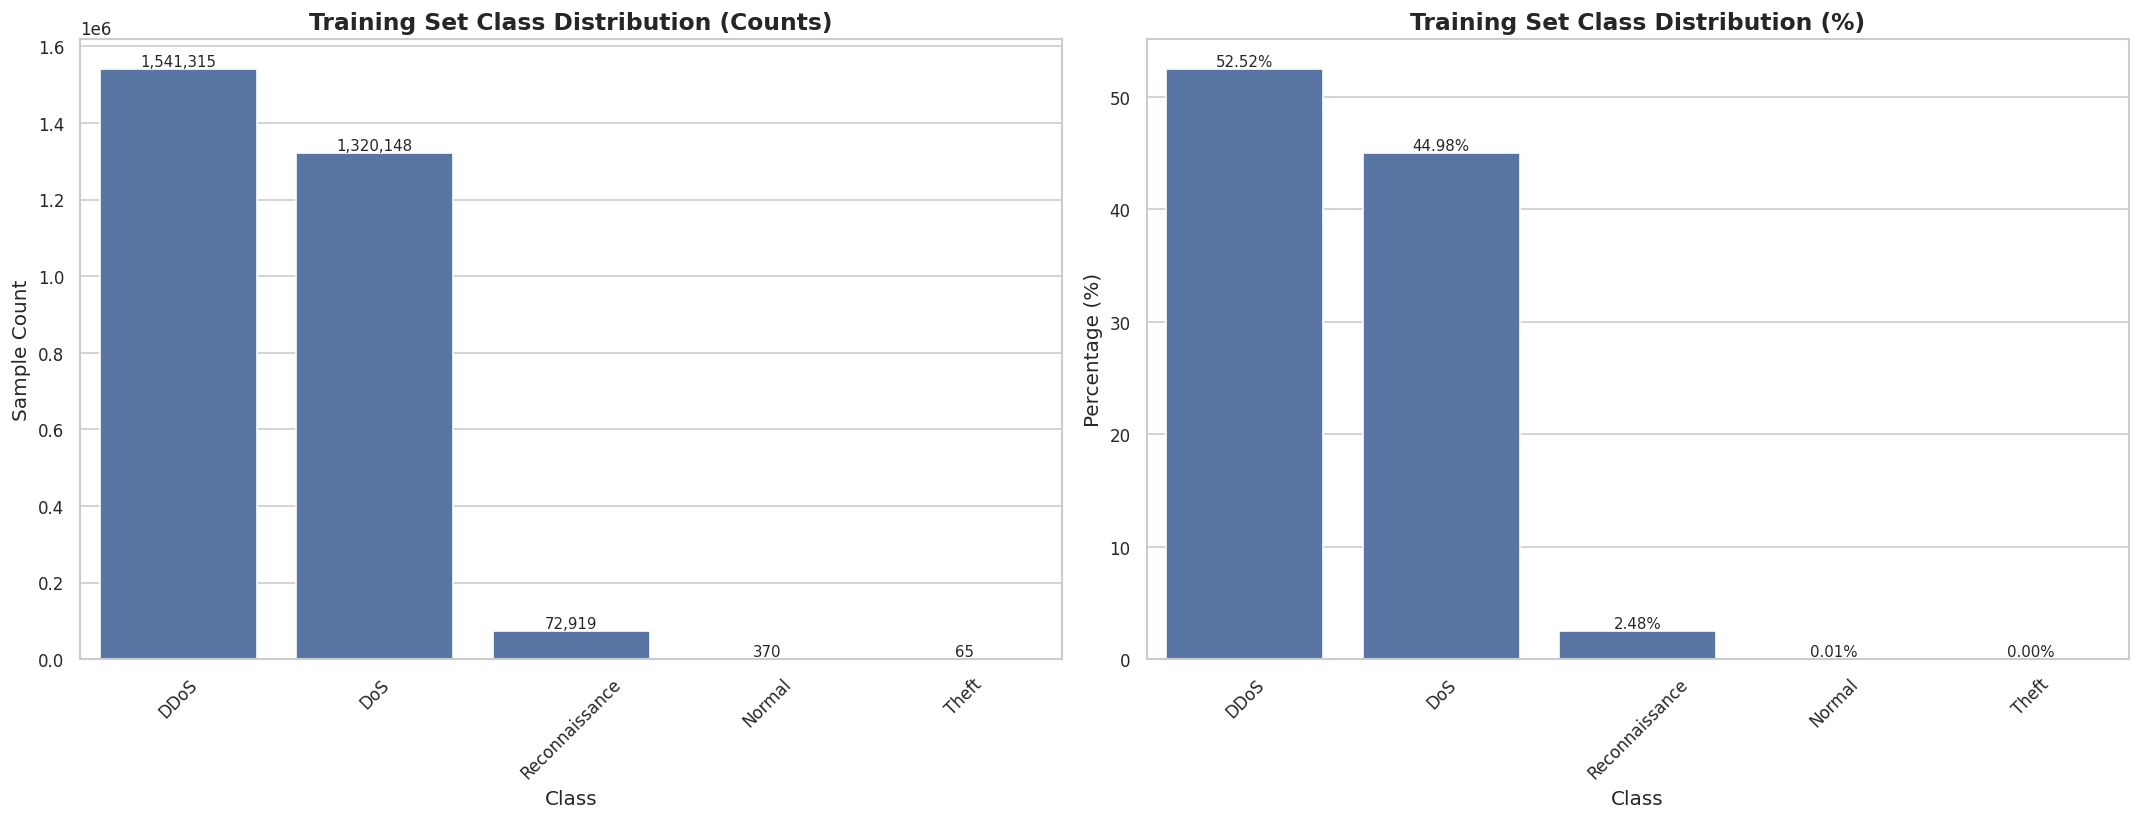

✅ Saved: /home/titoisalive/colide/notebooks/class_distribution_test.png


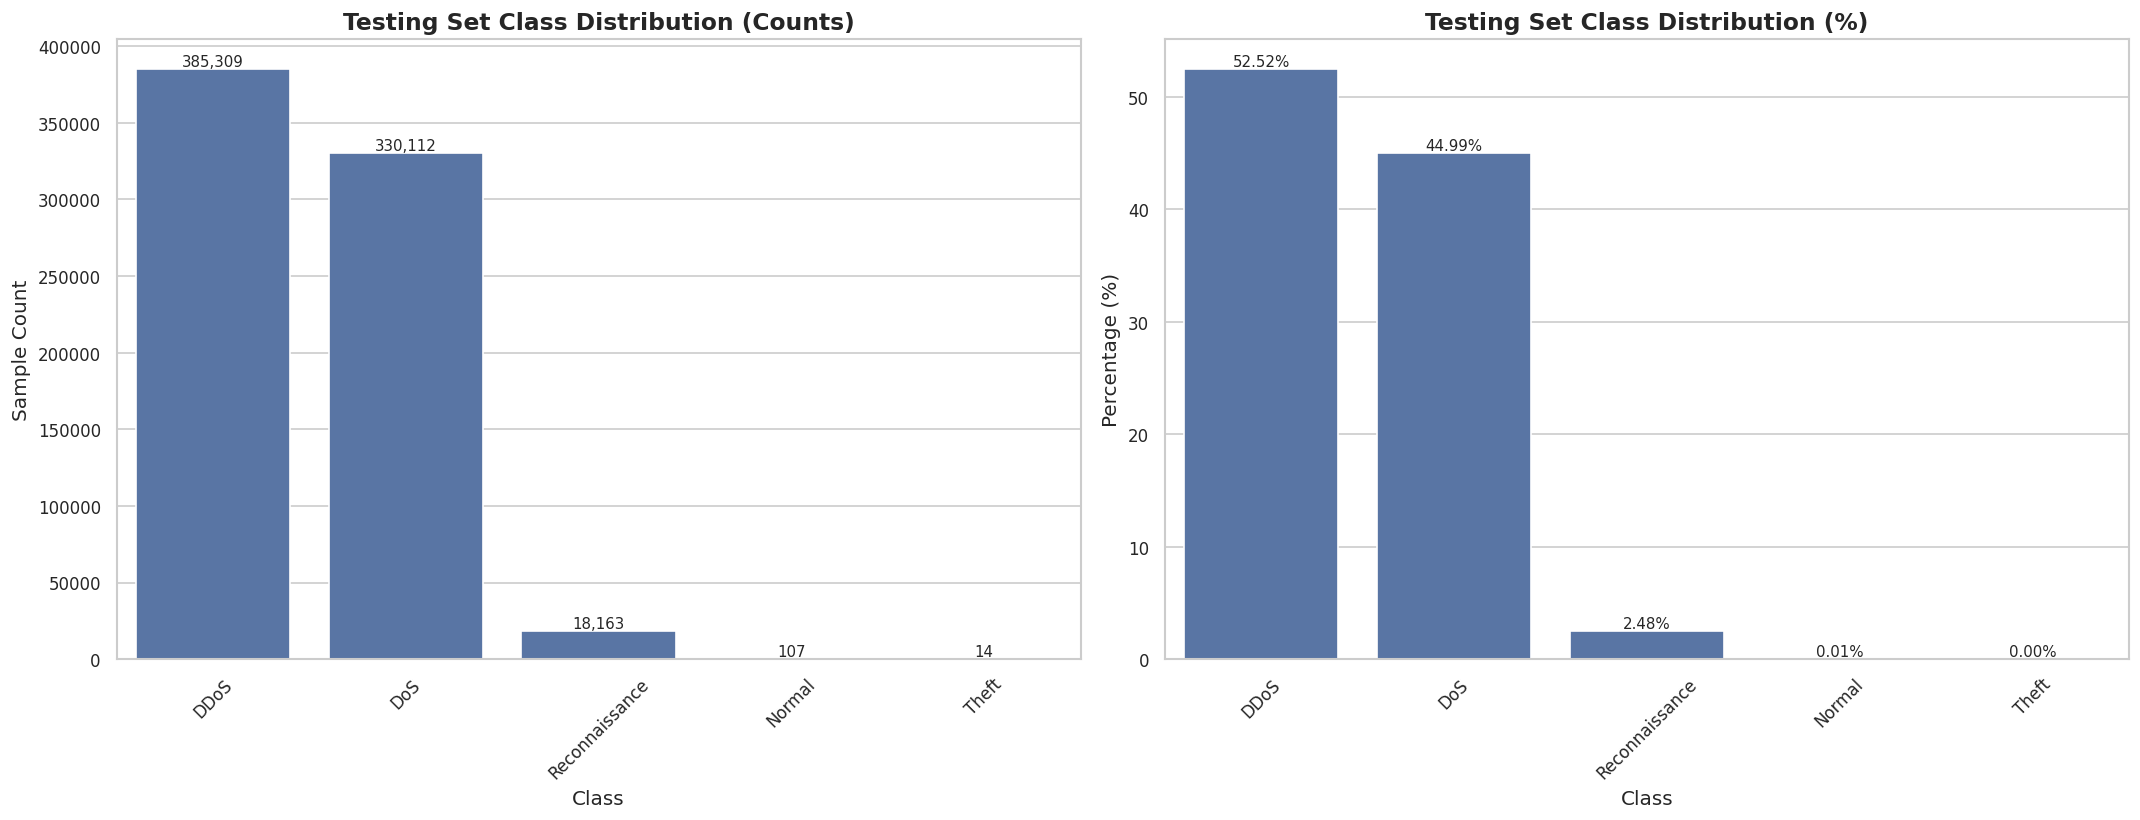


PLOT EXPORT VERIFICATION
Train Plot Exists : True
Test Plot Exists : True

Output Files:
• class_distribution_train.png
• class_distribution_test.png

✅ Class distribution plots complete


In [6]:
# ============================================================
# Cell 6: Class Distribution Visualizations
# ============================================================

# ------------------------------------------------------------
# Helper Function
# ------------------------------------------------------------
def plot_class_distribution(
    counts,
    percentages,
    dataset_name,
    output_path
):
    """
    Generate publication-grade class distribution plots.
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 7)
    )

    # ========================================================
    # Counts Plot
    # ========================================================
    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=axes[0]
    )

    axes[0].set_title(
        f"{dataset_name} Class Distribution (Counts)",
        fontsize=14,
        fontweight="bold"
    )

    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Sample Count")

    axes[0].tick_params(
        axis="x",
        rotation=45
    )

    # Annotate bars
    for i, value in enumerate(counts.values):

        axes[0].text(
            i,
            value,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # ========================================================
    # Percentage Plot
    # ========================================================
    sns.barplot(
        x=percentages.index,
        y=percentages.values,
        ax=axes[1]
    )

    axes[1].set_title(
        f"{dataset_name} Class Distribution (%)",
        fontsize=14,
        fontweight="bold"
    )

    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Percentage (%)")

    axes[1].tick_params(
        axis="x",
        rotation=45
    )

    # Annotate bars
    for i, value in enumerate(percentages.values):

        axes[1].text(
            i,
            value,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()

    # ========================================================
    # Save Figure
    # ========================================================
    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    print(f"✅ Saved: {output_path}")

    plt.show()


# ============================================================
# Training Set Visualization
# ============================================================

train_plot_path = (
    OUTPUT_DIR /
    "class_distribution_train.png"
)

plot_class_distribution(
    counts=TRAIN_CLASS_COUNTS,
    percentages=TRAIN_CLASS_PCT,
    dataset_name="Training Set",
    output_path=train_plot_path
)

# ============================================================
# Testing Set Visualization
# ============================================================

test_plot_path = (
    OUTPUT_DIR /
    "class_distribution_test.png"
)

plot_class_distribution(
    counts=TEST_CLASS_COUNTS,
    percentages=TEST_CLASS_PCT,
    dataset_name="Testing Set",
    output_path=test_plot_path
)

# ============================================================
# Verification
# ============================================================

print("\n" + "=" * 70)
print("PLOT EXPORT VERIFICATION")
print("=" * 70)

print(
    f"Train Plot Exists : "
    f"{train_plot_path.exists()}"
)

print(
    f"Test Plot Exists : "
    f"{test_plot_path.exists()}"
)

print("\nOutput Files:")

print(
    f"• {train_plot_path.name}"
)

print(
    f"• {test_plot_path.name}"
)

print("\n✅ Class distribution plots complete")

In [7]:
# ============================================================
# Cell 7: Feature Column Identification
# ============================================================

print("=" * 70)
print("FEATURE COLUMN IDENTIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Columns Excluded From Features
# ------------------------------------------------------------
ID_COLUMNS = [
    "pkSeqID"
]

TARGET_COLUMNS = [
    "attack",       # binary flag
    "category",     # multiclass target
    "subcategory"   # protocol / subtype
]

EXCLUDED_COLUMNS = (
    ID_COLUMNS +
    TARGET_COLUMNS
)

print("\nExcluded Columns")
print("-" * 70)

for col in EXCLUDED_COLUMNS:
    print(f"• {col}")

# ------------------------------------------------------------
# Raw Feature Columns
# ------------------------------------------------------------
feature_columns = sorted([
    col
    for col in df_train.columns
    if col not in EXCLUDED_COLUMNS
])

print("\n" + "=" * 70)
print("RAW FEATURE COLUMNS")
print("=" * 70)

print(f"Feature Count: {len(feature_columns)}\n")

for idx, col in enumerate(feature_columns, start=1):
    print(f"{idx:02d}. {col}")

# ------------------------------------------------------------
# Numeric Features
# ------------------------------------------------------------
numeric_feature_cols = sorted(

    df_train[feature_columns]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()

)

print("\n" + "=" * 70)
print("NUMERIC FEATURE COLUMNS")
print("=" * 70)

print(
    f"Numeric Feature Count: "
    f"{len(numeric_feature_cols)}"
)

print()

for idx, col in enumerate(
    numeric_feature_cols,
    start=1
):
    print(f"{idx:02d}. {col}")

# ------------------------------------------------------------
# Categorical Features
# ------------------------------------------------------------
categorical_feature_cols = sorted(

    list(
        set(feature_columns) -
        set(numeric_feature_cols)
    )

)

print("\n" + "=" * 70)
print("CATEGORICAL FEATURE COLUMNS")
print("=" * 70)

print(
    f"Categorical Feature Count: "
    f"{len(categorical_feature_cols)}"
)

print()

for idx, col in enumerate(
    categorical_feature_cols,
    start=1
):
    print(f"{idx:02d}. {col}")

# ------------------------------------------------------------
# Sanity Checks
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SANITY CHECKS")
print("=" * 70)

print(
    f"Raw Features       : "
    f"{len(feature_columns)}"
)

print(
    f"Numeric Features   : "
    f"{len(numeric_feature_cols)}"
)

print(
    f"Categorical Features : "
    f"{len(categorical_feature_cols)}"
)

print(
    f"Total Reconstructed : "
    f"{len(numeric_feature_cols) + len(categorical_feature_cols)}"
)

assert (
    len(feature_columns)
    ==
    len(numeric_feature_cols)
    +
    len(categorical_feature_cols)
)

# ------------------------------------------------------------
# High Cardinality Review
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CATEGORICAL FEATURE CARDINALITY")
print("=" * 70)

for col in categorical_feature_cols:

    unique_count = (
        df_train[col]
        .nunique()
    )

    print(
        f"{col:<15} "
        f"Unique Values: {unique_count:,}"
    )

# ------------------------------------------------------------
# Store For Later Cells
# ------------------------------------------------------------
RAW_FEATURE_COUNT = len(feature_columns)

NUMERIC_FEATURE_COUNT = len(
    numeric_feature_cols
)

CATEGORICAL_FEATURE_COUNT = len(
    categorical_feature_cols
)

print("\n✅ Feature identification complete")

FEATURE COLUMN IDENTIFICATION

Excluded Columns
----------------------------------------------------------------------
• pkSeqID
• attack
• category
• subcategory

RAW FEATURE COLUMNS
Feature Count: 15

01. N_IN_Conn_P_DstIP
02. N_IN_Conn_P_SrcIP
03. daddr
04. dport
05. drate
06. max
07. mean
08. min
09. proto
10. saddr
11. seq
12. sport
13. srate
14. state_number
15. stddev

NUMERIC FEATURE COLUMNS
Numeric Feature Count: 10

01. N_IN_Conn_P_DstIP
02. N_IN_Conn_P_SrcIP
03. drate
04. max
05. mean
06. min
07. seq
08. srate
09. state_number
10. stddev

CATEGORICAL FEATURE COLUMNS
Categorical Feature Count: 5

01. daddr
02. dport
03. proto
04. saddr
05. sport

SANITY CHECKS
Raw Features       : 15
Numeric Features   : 10
Categorical Features : 5
Total Reconstructed : 15

CATEGORICAL FEATURE CARDINALITY
daddr           Unique Values: 81
dport           Unique Values: 6,906
proto           Unique Values: 5
saddr           Unique Values: 20
sport           Unique Values: 65,541

✅ Feature ide

In [9]:
# ============================================================
# Cell 8: Numeric Feature Analysis & Feature Cleaning
# ============================================================

print("=" * 70)
print("NUMERIC FEATURE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Statistical Summary
# ------------------------------------------------------------
print("\nStatistical Summary (Numeric Features)")

numeric_summary = (
    df_train[numeric_feature_cols]
    .describe()
    .T
)

display(numeric_summary)

# ------------------------------------------------------------
# Zero Variance Analysis
# Training Set Only
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("ZERO VARIANCE ANALYSIS")
print("=" * 70)

feature_variances = (
    df_train[numeric_feature_cols]
    .var()
)

zero_variance_cols = sorted(
    feature_variances[
        feature_variances == 0
    ].index.tolist()
)

print(
    f"Zero Variance Features: "
    f"{len(zero_variance_cols)}"
)

print(zero_variance_cols)

# ------------------------------------------------------------
# Near-Constant Analysis
# Threshold = 99.9%
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("NEAR-CONSTANT FEATURE ANALYSIS")
print("=" * 70)

near_constant_cols = []

for col in numeric_feature_cols:

    dominant_ratio = (

        df_train[col]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .iloc[0]

    )

    if dominant_ratio >= 0.999:

        near_constant_cols.append(col)

near_constant_cols = sorted(
    near_constant_cols
)

print(
    f"Near-Constant Features: "
    f"{len(near_constant_cols)}"
)

print(near_constant_cols)

# ------------------------------------------------------------
# Duplicate Column Detection
# Skipped intentionally for scalability
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DUPLICATE COLUMN ANALYSIS")
print("=" * 70)

print(
    "Skipped for EDA scalability "
    "(2.9M+ training rows)"
)

duplicate_cols = []

# ------------------------------------------------------------
# Build Drop List
# ------------------------------------------------------------
columns_to_drop = sorted(

    list(
        set(
            zero_variance_cols +
            near_constant_cols
        )
    )

)

# ------------------------------------------------------------
# Clean Numeric Feature List
# ------------------------------------------------------------
clean_feature_cols = sorted([

    col

    for col in numeric_feature_cols

    if col not in columns_to_drop

])

# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FEATURE CLEANING SUMMARY")
print("=" * 70)

print(
    f"Original Numeric Features : "
    f"{len(numeric_feature_cols)}"
)

print(
    f"Zero Variance Removed     : "
    f"{len(zero_variance_cols)}"
)

print(
    f"Near Constant Removed     : "
    f"{len(near_constant_cols)}"
)

print(
    f"Final Clean Features      : "
    f"{len(clean_feature_cols)}"
)

print("\nClean Feature Columns")

for idx, col in enumerate(
    clean_feature_cols,
    start=1
):
    print(f"{idx:02d}. {col}")

# ------------------------------------------------------------
# Store For Later Cells
# ------------------------------------------------------------
ZERO_VARIANCE_COLS = zero_variance_cols
NEAR_CONSTANT_COLS = near_constant_cols
DUPLICATE_COLS = duplicate_cols

COLUMNS_TO_DROP = columns_to_drop

CLEAN_FEATURE_COUNT = len(
    clean_feature_cols
)

# ------------------------------------------------------------
# Sanity Check
# ------------------------------------------------------------
assert len(clean_feature_cols) > 0, \
    "No features remaining after cleaning."

print("\n✅ clean_feature_cols created successfully")
print("✅ Cell 8 Complete")

NUMERIC FEATURE ANALYSIS

Statistical Summary (Numeric Features)


,count,mean,std,min,25%,50%,75%,max
N_IN_Conn_P_DstIP,2934817.0000,92.4577,18.1665,1.0000,100.0000,100.0000,100.0000,100.0000
N_IN_Conn_P_SrcIP,2934817.0000,82.5500,24.3902,1.0000,69.0000,100.0000,100.0000,100.0000
drate,2934817.0000,0.4303,56.2330,0.0000,0.0000,0.0000,0.0000,58823.5273
max,2934817.0000,3.0193,1.8609,0.0000,0.2804,4.0084,4.2924,5.0000
mean,2934817.0000,2.2305,1.5178,0.0000,0.1819,2.6900,3.5651,4.9819
min,2934817.0000,1.0172,1.4836,0.0000,0.0000,0.0000,2.1479,4.9805
seq,2934817.0000,121297.3152,75786.9986,1.0000,54847.0000,117737.0000,184870.0000,262211.0000
srate,2934817.0000,3.1283,784.5494,0.0000,0.1558,0.2838,0.4880,1000000.0000
state_number,2934817.0000,3.1342,1.1871,1.0000,3.0000,4.0000,4.0000,11.0000
stddev,2934817.0000,0.8870,0.8036,0.0000,0.0300,0.7926,1.7452,2.4968



ZERO VARIANCE ANALYSIS
Zero Variance Features: 0
[]

NEAR-CONSTANT FEATURE ANALYSIS
Near-Constant Features: 0
[]

DUPLICATE COLUMN ANALYSIS
Skipped for EDA scalability (2.9M+ training rows)

FEATURE CLEANING SUMMARY
Original Numeric Features : 10
Zero Variance Removed     : 0
Near Constant Removed     : 0
Final Clean Features      : 10

Clean Feature Columns
01. N_IN_Conn_P_DstIP
02. N_IN_Conn_P_SrcIP
03. drate
04. max
05. mean
06. min
07. seq
08. srate
09. state_number
10. stddev

✅ clean_feature_cols created successfully
✅ Cell 8 Complete


In [10]:
print(clean_feature_cols)
print(len(clean_feature_cols))

['N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'drate', 'max', 'mean', 'min', 'seq', 'srate', 'state_number', 'stddev']
10


FEATURE CORRELATION ANALYSIS

Correlation Matrix:


,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,drate,max,mean,min,seq,srate,state_number,stddev
N_IN_Conn_P_DstIP,1.0000,0.5757,-0.0035,0.1012,0.1201,0.1035,0.0528,-0.0044,-0.0479,0.0405
N_IN_Conn_P_SrcIP,0.5757,1.0000,-0.0083,0.0652,0.0617,0.0284,0.0669,-0.0055,0.0360,0.0414
drate,-0.0035,-0.0083,1.0000,-0.0122,-0.0110,-0.0051,-0.0112,0.0369,-0.0037,-0.0084
max,0.1012,0.0652,-0.0122,1.0000,0.9087,0.4271,0.0723,-0.0054,0.5651,0.6682
mean,0.1201,0.0617,-0.0110,0.9087,1.0000,0.6940,0.0591,-0.0048,0.5715,0.3506
min,0.1035,0.0284,-0.0051,0.4271,0.6940,1.0000,0.0164,-0.0021,0.2751,-0.3759
seq,0.0528,0.0669,-0.0112,0.0723,0.0591,0.0164,1.0000,-0.0047,0.0519,0.0718
srate,-0.0044,-0.0055,0.0369,-0.0054,-0.0048,-0.0021,-0.0047,1.0000,-0.0044,-0.0038
state_number,-0.0479,0.0360,-0.0037,0.5651,0.5715,0.2751,0.0519,-0.0044,1.0000,0.3399
stddev,0.0405,0.0414,-0.0084,0.6682,0.3506,-0.3759,0.0718,-0.0038,0.3399,1.0000


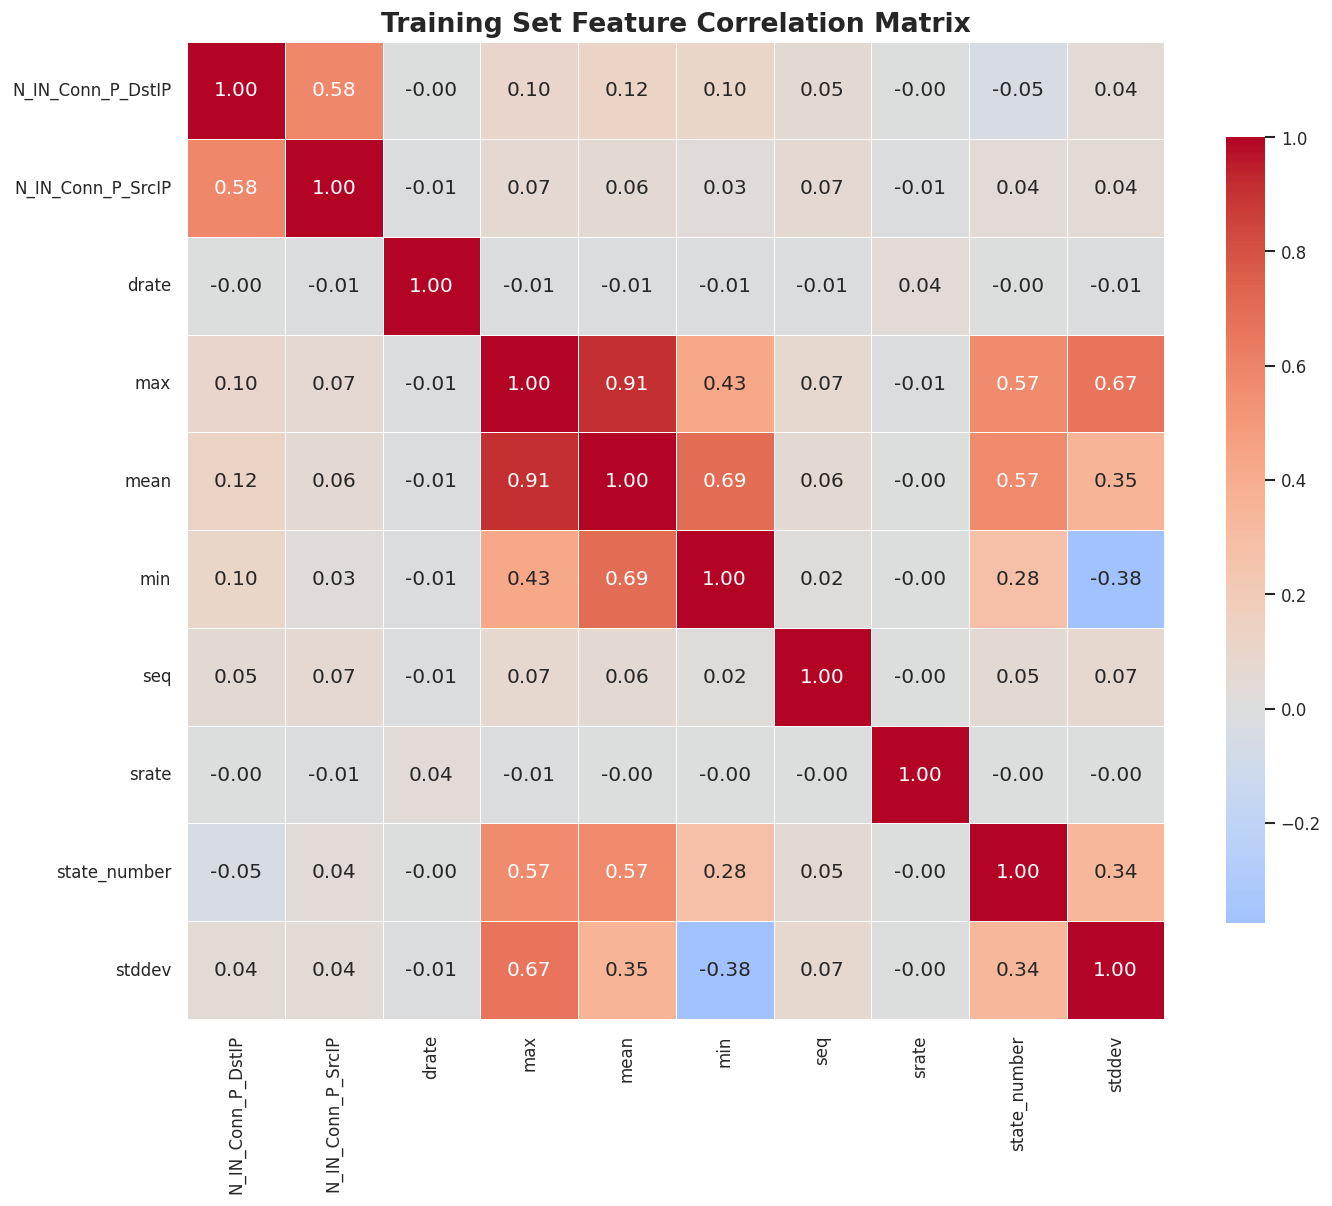


✅ Correlation heatmap saved to:
/home/titoisalive/colide/notebooks/feature_correlation.png

HIGH CORRELATION PAIRS


,Feature_A,Feature_B,Correlation
0,max,mean,0.9087



TOP ABSOLUTE CORRELATIONS


,Feature_A,Feature_B,Absolute_Correlation
0,max,mean,0.9087
1,mean,min,0.6940
2,max,stddev,0.6682
3,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,0.5757
4,mean,state_number,0.5715
5,max,state_number,0.5651
6,max,min,0.4271
7,min,stddev,0.3759
8,mean,stddev,0.3506
9,state_number,stddev,0.3399



✅ Correlation analysis complete


In [11]:
# ============================================================
# Cell 9: Feature Correlation Analysis
# ============================================================

print("=" * 70)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------
correlation_matrix = (
    df_train[clean_feature_cols]
    .corr()
)

print("\nCorrelation Matrix:")
display(correlation_matrix)

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,           # only 10 features -> readable
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Training Set Feature Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------
correlation_plot_path = (
    OUTPUT_DIR /
    "feature_correlation.png"
)

plt.savefig(
    correlation_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"\n✅ Correlation heatmap saved to:\n"
    f"{correlation_plot_path}"
)

# ------------------------------------------------------------
# High Correlation Detection
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("HIGH CORRELATION PAIRS")
print("=" * 70)

HIGH_CORR_THRESHOLD = 0.90

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= HIGH_CORR_THRESHOLD:

            high_corr_pairs.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    corr_value
                )
            )

if len(high_corr_pairs) == 0:

    print(
        f"No feature pairs found with "
        f"|correlation| >= {HIGH_CORR_THRESHOLD}"
    )

else:

    high_corr_pairs = sorted(
        high_corr_pairs,
        key=lambda x: abs(x[2]),
        reverse=True
    )

    high_corr_df = pd.DataFrame(
        high_corr_pairs,
        columns=[
            "Feature_A",
            "Feature_B",
            "Correlation"
        ]
    )

    display(high_corr_df)

# ------------------------------------------------------------
# Top Correlations Overview
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TOP ABSOLUTE CORRELATIONS")
print("=" * 70)

corr_abs = correlation_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

top_corr = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

display(
    top_corr.reset_index().rename(
        columns={
            "level_0": "Feature_A",
            "level_1": "Feature_B",
            0: "Absolute_Correlation"
        }
    )
)

print("\n✅ Correlation analysis complete")

In [13]:
# ------------------------------------------------------------
# Correlation Findings Import
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CORRELATION FINDINGS")
print("=" * 70)

try:

    HIGH_CORRELATION_PAIRS = high_corr_pairs

except NameError:

    HIGH_CORRELATION_PAIRS = []

print(
    f"High Correlation Pairs Found: "
    f"{len(HIGH_CORRELATION_PAIRS)}"
)

if len(HIGH_CORRELATION_PAIRS) > 0:

    high_corr_summary = pd.DataFrame(
        HIGH_CORRELATION_PAIRS,
        columns=[
            "Feature_A",
            "Feature_B",
            "Correlation"
        ]
    )

    display(high_corr_summary)

else:

    print(
        "No feature pairs exceeded "
        "the correlation threshold."
    )

# ------------------------------------------------------------
# EDA Notes For Final Summary
# ------------------------------------------------------------
EDA_NOTES = []

if len(HIGH_CORRELATION_PAIRS) > 0:

    EDA_NOTES.append(
        f"{len(HIGH_CORRELATION_PAIRS)} high-correlation "
        f"feature pair(s) detected."
    )

if len(ZERO_VARIANCE_COLS) == 0:

    EDA_NOTES.append(
        "No zero-variance features detected."
    )

if len(NEAR_CONSTANT_COLS) == 0:

    EDA_NOTES.append(
        "No near-constant features detected."
    )

print("\nEDA Notes")
print("-" * 70)

for note in EDA_NOTES:

    print(f"• {note}")

print("\n✅ Correlation metadata stored")
print("✅ Cell 10 Complete")


CORRELATION FINDINGS
High Correlation Pairs Found: 1


,Feature_A,Feature_B,Correlation
0,max,mean,0.9087



EDA Notes
----------------------------------------------------------------------
• 1 high-correlation feature pair(s) detected.
• No zero-variance features detected.
• No near-constant features detected.

✅ Correlation metadata stored
✅ Cell 10 Complete


In [14]:
# ============================================================
# Cell 11: Auto-update config.yaml
# ============================================================

print("=" * 70)
print("UPDATING CONFIG.YAML")
print("=" * 70)

# ------------------------------------------------------------
# Class Metadata
# ------------------------------------------------------------
class_names = sorted(
    df_train[LABEL_COL]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

num_classes = len(class_names)

# ------------------------------------------------------------
# Update Config Values
# ------------------------------------------------------------
config["data"]["num_classes"] = int(
    num_classes
)

config["data"]["feature_columns"] = (
    sorted(clean_feature_cols)
)

config["data"]["label_column"] = (
    LABEL_COL
)

config["data"]["class_names"] = (
    class_names
)

# ------------------------------------------------------------
# Model Section
# ------------------------------------------------------------
config["model"]["input_features"] = (
    len(clean_feature_cols)
)

config["model"]["num_classes"] = (
    int(num_classes)
)

# ------------------------------------------------------------
# Save Updated Config
# ------------------------------------------------------------
with open(
    CONFIG_PATH,
    "w"
) as file:

    yaml.dump(
        config,
        file,
        sort_keys=False,
        default_flow_style=False
    )

# ------------------------------------------------------------
# Confirmation Report
# ------------------------------------------------------------
print("\nUpdated Fields")
print("-" * 70)

print(
    f"data.num_classes      = "
    f"{num_classes}"
)

print(
    f"data.label_column     = "
    f"{LABEL_COL}"
)

print(
    f"data.feature_columns  = "
    f"{len(clean_feature_cols)} features"
)

print(
    f"data.class_names      = "
    f"{class_names}"
)

print(
    f"model.input_features  = "
    f"{len(clean_feature_cols)}"
)

print(
    f"model.num_classes     = "
    f"{num_classes}"
)

print("\nSaved To")
print("-" * 70)
print(CONFIG_PATH)

print("\n✅ config.yaml updated successfully")
print("✅ Cell 11 Complete")

UPDATING CONFIG.YAML

Updated Fields
----------------------------------------------------------------------
data.num_classes      = 5
data.label_column     = category
data.feature_columns  = 10 features
data.class_names      = ['DDoS', 'DoS', 'Normal', 'Reconnaissance', 'Theft']
model.input_features  = 10
model.num_classes     = 5

Saved To
----------------------------------------------------------------------
/home/titoisalive/colide/config/config.yaml

✅ config.yaml updated successfully
✅ Cell 11 Complete


In [15]:
# ============================================================
# Cell 12: Final EDA Summary
# ============================================================

print("=" * 90)
print("COLIDE EDA SUMMARY")
print("=" * 90)

# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------
print("\nDATASET OVERVIEW")
print("-" * 90)

print(
    f"Training Samples : "
    f"{len(df_train):,}"
)

print(
    f"Testing Samples  : "
    f"{len(df_test):,}"
)

# ------------------------------------------------------------
# Feature Overview
# ------------------------------------------------------------
print("\nFEATURE OVERVIEW")
print("-" * 90)

print(
    f"Raw Features         : "
    f"{RAW_FEATURE_COUNT}"
)

print(
    f"Numeric Features     : "
    f"{NUMERIC_FEATURE_COUNT}"
)

print(
    f"Categorical Features : "
    f"{CATEGORICAL_FEATURE_COUNT}"
)

print(
    f"Clean Features       : "
    f"{CLEAN_FEATURE_COUNT}"
)

# ------------------------------------------------------------
# Label Information
# ------------------------------------------------------------
print("\nLABEL INFORMATION")
print("-" * 90)

print(
    f"Label Column : "
    f"{LABEL_COL}"
)

print(
    f"Number of Classes : "
    f"{len(class_names)}"
)

print("\nClasses:")

for cls in class_names:

    count = TRAIN_CLASS_COUNTS.get(
        cls,
        0
    )

    pct = TRAIN_CLASS_PCT.get(
        cls,
        0
    )

    print(
        f"{cls:<20} "
        f"{count:>12,} "
        f"({pct:.4f}%)"
    )

# ------------------------------------------------------------
# Imbalance
# ------------------------------------------------------------
print("\nCLASS IMBALANCE")
print("-" * 90)

print(
    f"Imbalance Ratio : "
    f"{IMBALANCE_RATIO:.4f}"
)

# ------------------------------------------------------------
# Removed Features
# ------------------------------------------------------------
print("\nREMOVED FEATURES")
print("-" * 90)

print(
    f"Zero Variance : "
    f"{ZERO_VARIANCE_COLS}"
)

print(
    f"Near Constant : "
    f"{NEAR_CONSTANT_COLS}"
)

print(
    f"Duplicate     : "
    f"{DUPLICATE_COLS}"
)

# ------------------------------------------------------------
# Correlation Findings
# ------------------------------------------------------------
print("\nHIGH CORRELATION PAIRS")
print("-" * 90)

if len(HIGH_CORRELATION_PAIRS) == 0:

    print("None")

else:

    for pair in HIGH_CORRELATION_PAIRS:

        print(
            f"{pair[0]} <-> "
            f"{pair[1]} "
            f"({pair[2]:.4f})"
        )

# ------------------------------------------------------------
# Data Quality
# ------------------------------------------------------------
print("\nDATA QUALITY")
print("-" * 90)

print(
    f"Training Missing Cells : "
    f"{train_total_missing:,}"
)

print(
    f"Testing Missing Cells  : "
    f"{test_total_missing:,}"
)

print(
    f"Training Duplicate Rows : "
    f"{train_duplicate_rows:,}"
)

print(
    f"Testing Duplicate Rows  : "
    f"{test_duplicate_rows:,}"
)

# ------------------------------------------------------------
# Memory Usage
# ------------------------------------------------------------
print("\nMEMORY USAGE")
print("-" * 90)

print(
    f"Training Dataset : "
    f"{train_mem:.2f} MB"
)

print(
    f"Testing Dataset : "
    f"{test_mem:.2f} MB"
)

# ------------------------------------------------------------
# Generated Artifacts
# ------------------------------------------------------------
print("\nGENERATED FILES")
print("-" * 90)

print("class_distribution_train.png")
print("class_distribution_test.png")
print("feature_correlation.png")

# ------------------------------------------------------------
# EDA Notes
# ------------------------------------------------------------
print("\nEDA NOTES")
print("-" * 90)

for note in EDA_NOTES:

    print(f"• {note}")

print("\n✅ EDA COMPLETED SUCCESSFULLY")
print("✅ CONFIG UPDATED")
print("✅ READY FOR PREPROCESSING")

COLIDE EDA SUMMARY

DATASET OVERVIEW
------------------------------------------------------------------------------------------
Training Samples : 2,934,817
Testing Samples  : 733,705

FEATURE OVERVIEW
------------------------------------------------------------------------------------------
Raw Features         : 15
Numeric Features     : 10
Categorical Features : 5
Clean Features       : 10

LABEL INFORMATION
------------------------------------------------------------------------------------------
Label Column : category
Number of Classes : 5

Classes:
DDoS                    1,541,315 (52.5183%)
DoS                     1,320,148 (44.9823%)
Normal                        370 (0.0126%)
Reconnaissance             72,919 (2.4846%)
Theft                          65 (0.0022%)

CLASS IMBALANCE
------------------------------------------------------------------------------------------
Imbalance Ratio : 23712.5385

REMOVED FEATURES
-------------------------------------------------------------